=============================================================================
RESPIRATORY DISEASE CLASSIFIER — LAYER 1: XGBoost
=============================================================================
PURPOSE:
  Binary classification: Healthy (0) vs Diseased (1)
  Diseased = asthma, copd, covid-19 (all labelled as 1)
  Input: Pre-extracted CSV features (120 features + ID column)
  Output: Trained XGBoostClassifier saved to disk

USAGE (Google Colab with SSD-mounted data):
  - Mount your SSD via Colab's file browser or direct path
  - Update file paths in the CONFIG section below
  - Run each section sequentially

METRICS REPORTED: Accuracy, Precision, Recall, F1 (macro + per class),
                  Confusion Matrix, AUC-ROC
=============================================================================

In [1]:
# train data

from google.colab import files
uploaded = files.upload()

Saving processed_train_vowel_and_cough_ros.csv to processed_train_vowel_and_cough_ros (2).csv


In [2]:
# validate data

from google.colab import files
uploaded = files.upload()

Saving processed_val_vowel_and_cough.csv to processed_val_vowel_and_cough (1).csv


In [3]:
# test data

from google.colab import files
uploaded = files.upload()

Saving processed_test_vowel_and_cough.csv to processed_test_vowel_and_cough (1).csv


=============================================================================
SECTION 0: INSTALL & IMPORT DEPENDENCIES
=============================================================================

In [4]:
import pandas as pd                  # CSV reading and dataframe operations
import numpy as np                   # Numerical operations
import matplotlib.pyplot as plt      # Plotting
import seaborn as sns                # Styled heatmap for confusion matrix
import os                            # File path operations
import time                          # Track training duration

In [5]:
# XGBoost
from xgboost import XGBClassifier    # The main model

In [6]:
# Scikit-learn metrics and utilities
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

=============================================================================
SECTION 1: CONFIGURATION — UPDATE THESE PATHS BEFORE RUNNING
=============================================================================

In [7]:
CONFIG = {
    # Path to your training CSV file
    "train_csv": "processed_train_vowel_and_cough_ros.csv",

    # Path to your validation CSV file
    "val_csv": "processed_val_vowel_and_cough.csv",

    # Path to your test CSV file
    "test_csv": "processed_test_vowel_and_cough.csv",

    # Column name for the unique ID (first column — will be dropped)
    "id_col": "id",

    # Column name for the disease/class label in your CSV
    # Should contain: 'asthma', 'copd', 'covid', 'healthy' (or similar)
    "label_col": "disease",

    # Directory where trained model will be saved
    "save_dir": "/content/saved_models",

    # Filename for the saved HistGradientBoosting model
    "model_filename": "layer1_histgradboost.joblib",

    # Whether to plot and save the confusion matrix figure
    "save_plots": False,
}

In [8]:
# Create the save directory if it doesn't exist
os.makedirs(CONFIG["save_dir"], exist_ok=True)
print(f"[CONFIG] Save directory: {CONFIG['save_dir']}")

[CONFIG] Save directory: /content/saved_models


=============================================================================
SECTION 2: DATA LOADING & BINARISATION
=============================================================================

In [9]:
def load_and_binarise(csv_path, id_col, label_col):
    """
    Loads a CSV file, drops the ID column, and binarises the target label.

    Binarisation:
        healthy  → 0  (negative class)
        asthma   → 1  (positive / diseased)
        copd     → 1  (positive / diseased)
        covid    → 1  (positive / diseased)

    Args:
        csv_path  (str): Full path to the CSV file.
        id_col    (str): Column name for the unique sample ID (to drop).
        label_col (str): Column name for the disease/class label.

    Returns:
        X (pd.DataFrame): Feature matrix without ID or label columns.
        y (pd.Series)   : Binary label series (0 = healthy, 1 = diseased).
    """

    print(f"\n[DATA] Loading: {csv_path}")
    df = pd.read_csv(csv_path)
    print(f"[DATA] Raw shape: {df.shape}")

    # --- Drop ID column (not a predictive feature) ---
    if id_col in df.columns:
        df = df.drop(columns=[id_col])
        print(f"[DATA] Dropped ID column: '{id_col}'")

    # --- Confirm label column exists ---
    assert label_col in df.columns, (
        f"Label column '{label_col}' not found. "
        f"Columns available: {list(df.columns)}"
    )

    # --- Binarise label ---
    # Convert to lowercase string first to handle casing differences
    raw_labels = df[label_col].astype(str).str.lower().str.strip()
    y = df[label_col].apply(lambda x: 0 if x == 3 else 1)

    # --- Separate features from labels ---
    X = df.drop(columns=[label_col])

    # --- Report class distribution ---
    n_healthy  = (y == 0).sum()
    n_diseased = (y == 1).sum()
    print(f"[DATA] Healthy (0): {n_healthy} | Diseased (1): {n_diseased}")
    print(f"[DATA] Feature matrix shape: {X.shape}")

    return X, y

In [10]:
# --- Load all three splits ---
X_train, y_train = load_and_binarise(
    CONFIG["train_csv"], CONFIG["id_col"], CONFIG["label_col"]
)
X_val, y_val = load_and_binarise(
    CONFIG["val_csv"], CONFIG["id_col"], CONFIG["label_col"]
)
X_test, y_test = load_and_binarise(
    CONFIG["test_csv"], CONFIG["id_col"], CONFIG["label_col"]
)


[DATA] Loading: processed_train_vowel_and_cough_ros.csv
[DATA] Raw shape: (10634, 121)
[DATA] Dropped ID column: 'id'
[DATA] Healthy (0): 3937 | Diseased (1): 6697
[DATA] Feature matrix shape: (10634, 119)

[DATA] Loading: processed_val_vowel_and_cough.csv
[DATA] Raw shape: (1772, 121)
[DATA] Dropped ID column: 'id'
[DATA] Healthy (0): 832 | Diseased (1): 940
[DATA] Feature matrix shape: (1772, 119)

[DATA] Loading: processed_test_vowel_and_cough.csv
[DATA] Raw shape: (1626, 121)
[DATA] Dropped ID column: 'id'
[DATA] Healthy (0): 840 | Diseased (1): 786
[DATA] Feature matrix shape: (1626, 119)


In [11]:
print(f"\n[DATA] Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


[DATA] Train: 10634 | Val: 1772 | Test: 1626


=============================================================================
SECTION 3: CLASS IMBALANCE — COMPUTE scale_pos_weight
=============================================================================
XGBoost uses scale_pos_weight to handle class imbalance.
Formula: scale_pos_weight = count(negative class) / count(positive class)
         = count(healthy) / count(diseased)
For a balanced dataset, this will be ~1.0 (no strong weighting).
With 4061 healthy out of 8015: ratio ≈ 4061 / 3954 ≈ 1.027

In [12]:
n_healthy_train  = (y_train == 0).sum()
n_diseased_train = (y_train == 1).sum()
scale_pos_weight = n_healthy_train / n_diseased_train

In [13]:
print(f"\n[IMBALANCE] scale_pos_weight = {scale_pos_weight:.4f}")
print("[IMBALANCE] Value close to 1.0 confirms near-balanced dataset.")


[IMBALANCE] scale_pos_weight = 0.5879
[IMBALANCE] Value close to 1.0 confirms near-balanced dataset.


=============================================================================
SECTION 4: PREPARE VALIDATION DATA FOR EARLY STOPPING
=============================================================================
XGBoost's early stopping requires an eval_set — we pass the validation set.
Training halts if eval metric doesn't improve for `early_stopping_rounds`.

In [14]:
eval_set = [(X_val, y_val)]   # XGBoost monitors this set during training

=============================================================================
SECTION 5: MODEL DEFINITION — XGBClassifier
=============================================================================

In [15]:
def build_xgboost(scale_pos_weight):
    """
    Builds and returns an XGBClassifier with recommended hyperparameters.

    Key parameter choices:
        n_estimators=500         : Maximum boosting rounds (early stopping halts earlier)
        learning_rate=0.05       : Slow step size for better generalisation
        max_depth=6              : Tree depth; deeper = more expressive but risky
        subsample=0.8            : Use 80% of training rows per tree (reduces variance)
        colsample_bytree=0.8     : Use 80% of features per tree (reduces overfitting)
        scale_pos_weight         : Corrects class imbalance (healthy/diseased ratio)
        eval_metric='auc'        : Monitor AUC on eval set during training
        use_label_encoder=False  : Suppress deprecated label encoder warning
        tree_method='hist'       : Fast histogram-based algorithm (good for Colab/GPU)
        device='cuda'            : Uses GPU if available; falls back to CPU automatically
        random_state=42          : Reproducibility seed

    Args:
        scale_pos_weight (float): Class weight ratio for imbalance correction.

    Returns:
        model: Untrained XGBClassifier instance.
    """

    model = XGBClassifier(
        n_estimators=500,           # Max boosting rounds
        learning_rate=0.05,         # Shrinkage step — smaller = slower but better
        max_depth=6,                # Depth of each tree
        subsample=0.8,              # Row subsampling fraction per tree
        colsample_bytree=0.8,       # Feature subsampling fraction per tree
        scale_pos_weight=scale_pos_weight,  # Class imbalance correction
        eval_metric="auc",          # Metric to watch for early stopping
        tree_method="hist",         # Histogram method — faster and GPU-compatible
        device="cuda",              # Try GPU first; XGBoost will fallback to CPU if unavailable
        random_state=42,            # Fix seed for reproducibility
        verbosity=1,                # 0=silent, 1=warnings, 2=info, 3=debug
    )

    print("\n[MODEL] XGBClassifier built with recommended params.")
    return model

=============================================================================
SECTION 6: TRAINING WITH EARLY STOPPING
=============================================================================

In [16]:
print("\n" + "="*60)
print("TRAINING: XGBClassifier")
print("="*60)


TRAINING: XGBClassifier


In [17]:
# Build the model
xgb_model = build_xgboost(scale_pos_weight)


[MODEL] XGBClassifier built with recommended params.


In [18]:
# Record training start time
start_time = time.time()

In [19]:
print(np.unique(y_train, return_counts=True))
print(np.unique(y_val, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0, 1]), array([3937, 6697]))
(array([0, 1]), array([832, 940]))
(array([0, 1]), array([840, 786]))


In [25]:
from xgboost import callback

In [27]:
# --- Fit the model ---
# early_stopping_rounds=20: stop if AUC on eval_set doesn't improve for 20 rounds
# verbose=50: print eval metric every 50 rounds

xgb_model = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    tree_method="hist"
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=eval_set,  # Monitor AUC on validation set
    verbose=50  # Print progress every 50 rounds
)

[0]	validation_0-auc:0.79849
[50]	validation_0-auc:0.90995
[100]	validation_0-auc:0.91173
[150]	validation_0-auc:0.91180
[200]	validation_0-auc:0.91140
[250]	validation_0-auc:0.91025
[300]	validation_0-auc:0.90990
[350]	validation_0-auc:0.90998
[400]	validation_0-auc:0.91018
[450]	validation_0-auc:0.91039
[500]	validation_0-auc:0.90967
[550]	validation_0-auc:0.90931
[600]	validation_0-auc:0.90952
[650]	validation_0-auc:0.91011
[700]	validation_0-auc:0.91028
[750]	validation_0-auc:0.90974
[800]	validation_0-auc:0.90925
[850]	validation_0-auc:0.90879
[900]	validation_0-auc:0.90888
[950]	validation_0-auc:0.90853
[1000]	validation_0-auc:0.90837
[1050]	validation_0-auc:0.90829
[1100]	validation_0-auc:0.90794
[1150]	validation_0-auc:0.90788
[1200]	validation_0-auc:0.90785
[1250]	validation_0-auc:0.90767
[1300]	validation_0-auc:0.90775
[1350]	validation_0-auc:0.90790
[1400]	validation_0-auc:0.90790
[1450]	validation_0-auc:0.90770
[1500]	validation_0-auc:0.90767
[1550]	validation_0-auc:0.90764

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=2000,
              n_jobs=None, num_parallel_tree=None, ...)

In [29]:
# Record training duration
train_duration = time.time() - start_time
print(f"\n[TRAIN] Training completed in {train_duration:.1f} seconds.")
print(f"[TRAIN] Trees used: {xgb_model.n_estimators}")


[TRAIN] Training completed in 754.2 seconds.
[TRAIN] Trees used: 2000


=============================================================================
SECTION 7: EVALUATION FUNCTION
=============================================================================

In [30]:
def evaluate_model(model, X, y_true, split_name="Test"):
    """
    Evaluates a binary classifier and prints a full metrics report.

    Metrics:
        Accuracy   : (TP + TN) / Total
        Precision  : TP / (TP + FP) — how many flagged positives are correct
        Recall     : TP / (TP + FN) — how many actual positives are caught
                     *** PRIMARY METRIC: recall for diseased class ***
                     (Missing a sick patient is worse than a false alarm)
        F1 Macro   : Harmonic mean of precision & recall, averaged across classes
                     *** PRIMARY METRIC: macro F1 for overall model quality ***
        AUC-ROC    : Area under ROC curve — threshold-independent measure
        Confusion Matrix: [TN FP / FN TP]

    Args:
        model      : Trained model with .predict() and .predict_proba() methods.
        X          : Feature matrix (pd.DataFrame or np.ndarray).
        y_true     : True binary labels (0 or 1).
        split_name : Label for the split (e.g., 'Validation', 'Test').

    Returns:
        metrics (dict): All computed metric values.
    """

    print(f"\n{'='*60}")
    print(f"EVALUATION — {split_name} Set")
    print(f"{'='*60}")

    # --- Predictions ---
    y_pred      = model.predict(X)
    y_pred_prob = model.predict_proba(X)[:, 1]   # Probability of class 1 (diseased)

    # --- Macro averages ---
    acc      = accuracy_score(y_true, y_pred)
    prec_mac = precision_score(y_true, y_pred, average="macro",  zero_division=0)
    rec_mac  = recall_score(y_true,    y_pred, average="macro",  zero_division=0)
    f1_mac   = f1_score(y_true,        y_pred, average="macro",  zero_division=0)

    # --- Per-class metrics ---
    # Returns array: index 0 = class 0 (healthy), index 1 = class 1 (diseased)
    prec_per = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec_per  = recall_score(y_true,    y_pred, average=None, zero_division=0)
    f1_per   = f1_score(y_true,        y_pred, average=None, zero_division=0)

    # --- AUC-ROC ---
    auc = roc_auc_score(y_true, y_pred_prob)

    # --- Print results ---
    print(f"\n  Accuracy          : {acc:.4f}")
    print(f"  AUC-ROC           : {auc:.4f}")
    print(f"\n  --- Macro Averages (PRIMARY METRICS) ---")
    print(f"  Precision (macro) : {prec_mac:.4f}")
    print(f"  Recall (macro)    : {rec_mac:.4f}  *** PRIMARY ***")
    print(f"  F1 (macro)        : {f1_mac:.4f}   *** PRIMARY ***")
    print(f"\n  --- Per-Class Breakdown ---")
    print(f"  {'Class':<14} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print(f"  {'-'*46}")
    for cls_idx, cls_name in enumerate(["Healthy (0)", "Diseased (1)"]):
        print(f"  {cls_name:<14} {prec_per[cls_idx]:>10.4f} "
              f"{rec_per[cls_idx]:>10.4f} {f1_per[cls_idx]:>10.4f}")

    # --- Full sklearn report with support counts ---
    print(f"\n  --- Full Classification Report ---")
    print(classification_report(
        y_true, y_pred,
        target_names=["Healthy (0)", "Diseased (1)"],
        zero_division=0
    ))

    # --- Confusion matrix ---
    cm = confusion_matrix(y_true, y_pred)
    print(f"  Confusion Matrix:")
    print(f"  [TN={cm[0,0]:5d}  FP={cm[0,1]:5d}]")
    print(f"  [FN={cm[1,0]:5d}  TP={cm[1,1]:5d}]")

    # --- Interpretation note for medical context ---
    fn_rate = cm[1,0] / (cm[1,0] + cm[1,1]) if (cm[1,0] + cm[1,1]) > 0 else 0
    print(f"\n  False Negative Rate (missed disease): {fn_rate:.4f}")
    print(f"  → {cm[1,0]} diseased patients incorrectly classified as healthy")

    # Pack everything into a dict for easy comparison
    metrics = {
        "split"              : split_name,
        "accuracy"           : acc,
        "auc_roc"            : auc,
        "precision_macro"    : prec_mac,
        "recall_macro"       : rec_mac,
        "f1_macro"           : f1_mac,
        "precision_per_class": prec_per,
        "recall_per_class"   : rec_per,
        "f1_per_class"       : f1_per,
        "confusion_matrix"   : cm,
        "fn_rate"            : fn_rate,
    }

    return metrics

=============================================================================
SECTION 8: CONFUSION MATRIX PLOT UTILITY
=============================================================================

In [31]:
def plot_confusion_matrix(cm, split_name, model_name, save_dir, save=True):
    """
    Plots a styled confusion matrix heatmap using seaborn.

    Args:
        cm         : 2x2 confusion matrix (from sklearn.metrics.confusion_matrix).
        split_name : "Validation" or "Test"
        model_name : "XGBoost"
        save_dir   : Directory to save the PNG.
        save       : If True, saves the figure to disk.
    """

    fig, ax = plt.subplots(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,           # Show numerical values in cells
        fmt="d",              # Integer format for cell annotations
        cmap="Oranges",       # Different colormap from HistGradBoost for easy comparison
        xticklabels=["Healthy (0)", "Diseased (1)"],
        yticklabels=["Healthy (0)", "Diseased (1)"],
        ax=ax,
        linewidths=0.5,
        linecolor="gray",
    )

    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    ax.set_title(f"{model_name} — {split_name} Confusion Matrix", fontsize=13)
    plt.tight_layout()

    if save:
        filename = f"{model_name}_{split_name}_confusion_matrix.png".replace(" ", "_")
        filepath = os.path.join(save_dir, filename)
        plt.savefig(filepath, dpi=150)
        print(f"[PLOT] Confusion matrix saved to: {filepath}")

    plt.show()

=============================================================================
SECTION 9: PLOT TRAINING HISTORY (AUC OVER ROUNDS)
=============================================================================

In [35]:
def plot_training_history(model, save_dir, save=True):
    """
    Plots AUC on the validation set across all boosting rounds.
    Useful for confirming early stopping triggered at the right point.

    Args:
        model    : Fitted XGBClassifier (must have evals_result_ attribute).
        save_dir : Directory to save the plot.
        save     : Whether to save the figure.
    """

    # evals_result_ is a dict: {'validation_0': {'auc': [...]}}
    results = model.evals_result()

    # The key name depends on what you passed in eval_set
    # If eval_set = [(X_val, y_val)], key = 'validation_0'
    val_auc = results.get("validation_0", {}).get("auc", [])

    if not val_auc:
        print("[PLOT] No training history found (evals_result_ is empty).")
        return

    plt.figure(figsize=(8, 4))
    plt.plot(val_auc, color="darkorange", linewidth=1.5, label="Val AUC")
    best_iter = getattr(model, "best_iteration", None)

    if best_iter is not None:
        plt.axvline(
            x=best_iter,
            color="red",
            linestyle="--",
            label=f"Best iteration: {best_iter}"
        )

    plt.xlabel("Boosting Round")
    plt.ylabel("AUC-ROC")
    plt.title("XGBoost: Validation AUC Over Training Rounds")
    plt.legend()
    plt.tight_layout()

    if save:
        filepath = os.path.join(save_dir, "XGBoost_training_history.png")
        plt.savefig(filepath, dpi=150)
        print(f"[PLOT] Training history saved to: {filepath}")

    plt.show()

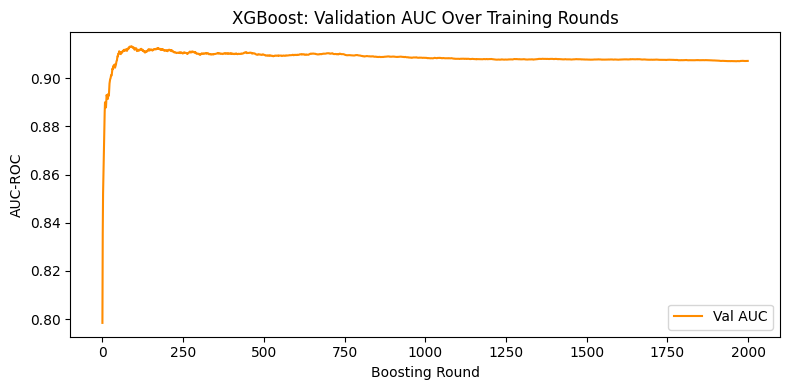

In [36]:
# Plot training AUC history
plot_training_history(xgb_model, CONFIG["save_dir"], save=CONFIG["save_plots"])

=============================================================================
SECTION 10: FEATURE IMPORTANCE PLOT
=============================================================================

In [37]:
def plot_feature_importance(model, feature_names, save_dir, top_n=30, save=True):
    """
    Plots the top N most important features by XGBoost's 'gain' importance.

    'Gain' = average improvement in the loss function brought by a feature
             across all splits where it was used. Higher = more useful.

    Args:
        model         : Fitted XGBClassifier.
        feature_names : List of feature column names.
        save_dir      : Directory to save the plot.
        top_n         : Number of top features to display.
        save          : Whether to save the plot.
    """

    # Get feature importances as a dict {feature_name: importance_score}
    importance_dict = model.get_booster().get_score(importance_type="gain")

    # Convert to sorted DataFrame
    imp_df = pd.DataFrame(
        list(importance_dict.items()),
        columns=["Feature", "Gain"]
    ).sort_values("Gain", ascending=False).head(top_n)

    # Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df, x="Gain", y="Feature", palette="viridis")
    plt.title(f"XGBoost: Top {top_n} Features by Gain", fontsize=13)
    plt.xlabel("Gain (Importance Score)")
    plt.ylabel("Feature")
    plt.tight_layout()

    if save:
        filepath = os.path.join(save_dir, f"XGBoost_feature_importance_top{top_n}.png")
        plt.savefig(filepath, dpi=150)
        print(f"[PLOT] Feature importance saved to: {filepath}")

    plt.show()

/tmp/ipykernel_9921/3644136086.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x="Gain", y="Feature", palette="viridis")


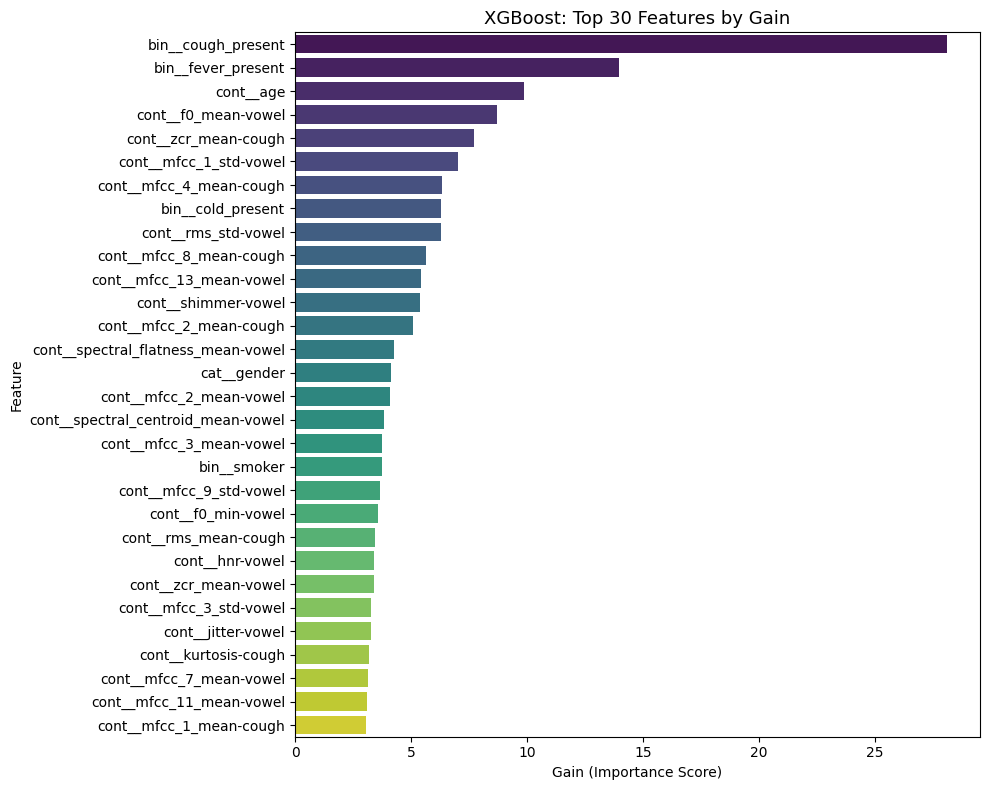

In [38]:
# Plot top 30 features by importance
plot_feature_importance(
    xgb_model,
    feature_names=list(X_train.columns),
    save_dir=CONFIG["save_dir"],
    top_n=30,
    save=CONFIG["save_plots"]
)

=============================================================================
SECTION 11: EVALUATE ON VALIDATION AND TEST SETS
=============================================================================

In [39]:
val_metrics  = evaluate_model(xgb_model, X_val,  y_val,  split_name="Validation")
test_metrics = evaluate_model(xgb_model, X_test, y_test, split_name="Test")


EVALUATION — Validation Set

  Accuracy          : 0.8471
  AUC-ROC           : 0.9071

  --- Macro Averages (PRIMARY METRICS) ---
  Precision (macro) : 0.8470
  Recall (macro)    : 0.8483  *** PRIMARY ***
  F1 (macro)        : 0.8469   *** PRIMARY ***

  --- Per-Class Breakdown ---
  Class           Precision     Recall         F1
  ----------------------------------------------
  Healthy (0)        0.8169     0.8690     0.8422
  Diseased (1)       0.8771     0.8277     0.8517

  --- Full Classification Report ---
              precision    recall  f1-score   support

 Healthy (0)       0.82      0.87      0.84       832
Diseased (1)       0.88      0.83      0.85       940

    accuracy                           0.85      1772
   macro avg       0.85      0.85      0.85      1772
weighted avg       0.85      0.85      0.85      1772

  Confusion Matrix:
  [TN=  723  FP=  109]
  [FN=  162  TP=  778]

  False Negative Rate (missed disease): 0.1723
  → 162 diseased patients incorrectly

[PLOT] Confusion matrix saved to: /content/saved_models/XGBoost_Validation_confusion_matrix.png


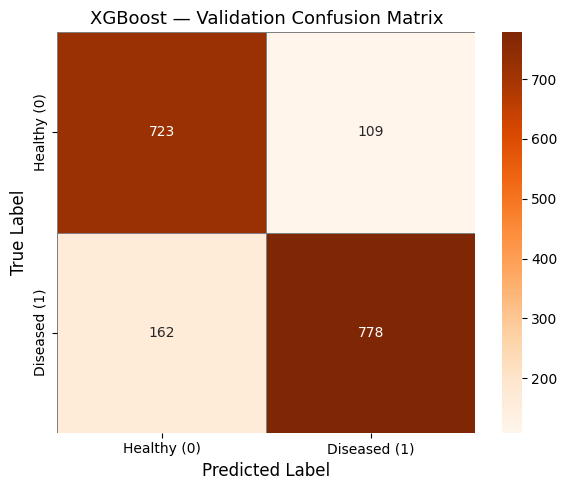

[PLOT] Confusion matrix saved to: /content/saved_models/XGBoost_Test_confusion_matrix.png


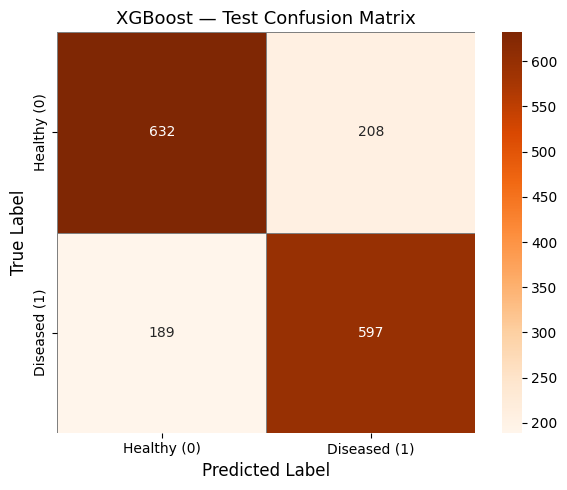

In [41]:
# Plot confusion matrices
plot_confusion_matrix(
    val_metrics["confusion_matrix"],
    split_name="Validation",
    model_name="XGBoost",
    save_dir=CONFIG["save_dir"],
)
plot_confusion_matrix(
    test_metrics["confusion_matrix"],
    split_name="Test",
    model_name="XGBoost",
    save_dir=CONFIG["save_dir"],
)

plt.show()

=============================================================================
SECTION 12: SAVE THE TRAINED XGBoost MODEL
=============================================================================

In [42]:
def save_xgboost_model(model, save_dir, filename):
    """
    Saves a trained XGBClassifier to disk in XGBoost's native binary format (.ubj).

    The .ubj (Universal Binary JSON) format is XGBoost's recommended format:
        - Smaller and faster than JSON or pickle
        - Platform-independent
        - Preserves all model parameters exactly

    Args:
        model    : Fitted XGBClassifier.
        save_dir : Directory to save the model.
        filename : Filename for the saved model (e.g., 'layer1_xgboost.ubj').

    Returns:
        save_path (str): Full path to the saved model file.
    """

    save_path = os.path.join(save_dir, filename)
    model.save_model(save_path)
    print(f"\n[SAVE] XGBoost model saved to: {save_path}")
    return save_path

In [49]:
# Save the model
xgb_save_path = save_xgboost_model(
    xgb_model,
    CONFIG["save_dir"],
    CONFIG["model_filename"]
)

from google.colab import files

files.download(xgb_save_path)

/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1116: UserWarning: [17:20:18] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1573: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)



[SAVE] XGBoost model saved to: /content/saved_models/layer1_histgradboost.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

=============================================================================
SECTION 13: VERIFY SAVED MODEL RELOADS CORRECTLY
=============================================================================

In [44]:
def verify_saved_model(save_path, X_sample, y_sample):
    """
    Reloads a saved XGBoost model and runs a quick sanity check
    to confirm the save/load cycle worked without corruption.

    Args:
        save_path : Full path to the .ubj model file.
        X_sample  : Small feature matrix for test predictions.
        y_sample  : Corresponding true labels.
    """

    print(f"\n[VERIFY] Reloading XGBoost model from: {save_path}")

    # Load into a fresh XGBClassifier instance
    reloaded = XGBClassifier()
    reloaded.load_model(save_path)

    # Predict on first 5 test samples
    sample_preds = reloaded.predict(X_sample.iloc[:5])
    sample_true  = y_sample.iloc[:5].values
    print(f"[VERIFY] True labels  : {sample_true}")
    print(f"[VERIFY] Predictions  : {sample_preds}")
    print("[VERIFY] Reload successful ✓")

In [45]:
verify_saved_model(xgb_save_path, X_test, y_test)


[VERIFY] Reloading XGBoost model from: /content/saved_models/layer1_histgradboost.joblib
[VERIFY] True labels  : [0 0 0 0 0]
[VERIFY] Predictions  : [0 0 0 0 0]
[VERIFY] Reload successful ✓


/usr/local/lib/python3.12/dist-packages/xgboost/sklearn.py:1125: UserWarning: [15:38:23] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1509: Unknown file format: `joblib`. Using UBJSON (`ubj`) as a guess.
  self.get_booster().load_model(fname)


=============================================================================
SECTION 14: SUMMARY
=============================================================================

In [48]:
print("\n" + "="*60)
print("FINAL SUMMARY — XGBoost Layer 1")
print("="*60)
print(f"  Val  Accuracy : {val_metrics['accuracy']:.4f}")
print(f"  Val  AUC-ROC  : {val_metrics['auc_roc']:.4f}")
print(f"  Val  F1 Macro : {val_metrics['f1_macro']:.4f}")
print(f"  Val  Recall M : {val_metrics['recall_macro']:.4f}")
print(f"  Val  FN Rate  : {val_metrics['fn_rate']:.4f}")
print(f"---")
print(f"  Test Accuracy : {test_metrics['accuracy']:.4f}")
print(f"  Test AUC-ROC  : {test_metrics['auc_roc']:.4f}")
print(f"  Test F1 Macro : {test_metrics['f1_macro']:.4f}")
print(f"  Test Recall M : {test_metrics['recall_macro']:.4f}")
print(f"  Test FN Rate  : {test_metrics['fn_rate']:.4f}")
best_iter = getattr(xgb_model, "best_iteration", None)

if best_iter is not None:
    print(f"\n  Best boosting round : {best_iter}")
else:
    print("\n  Best boosting round : Not available (no early stopping used)")
print(f"  Model saved at      : {xgb_save_path}")
print("="*60)
print("\n[NEXT] Compare these results with layer1_histgradboost.py")
print("[NEXT] Choose the better model, then proceed to layer2_cnn.py")


FINAL SUMMARY — XGBoost Layer 1
  Val  Accuracy : 0.8471
  Val  AUC-ROC  : 0.9071
  Val  F1 Macro : 0.8469
  Val  Recall M : 0.8483
  Val  FN Rate  : 0.1723
---
  Test Accuracy : 0.7558
  Test AUC-ROC  : 0.8392
  Test F1 Macro : 0.7557
  Test Recall M : 0.7560
  Test FN Rate  : 0.2405

  Best boosting round : Not available (no early stopping used)
  Model saved at      : /content/saved_models/layer1_histgradboost.joblib

[NEXT] Compare these results with layer1_histgradboost.py
[NEXT] Choose the better model, then proceed to layer2_cnn.py


=============================================================================
END OF FILE: layer1_xgboost.py
=============================================================================